# Assignment 2 : Language Modeling & Evaluation 

**Student names**: Kirsten Thaulow, Nora Børaas <br>
**Group number**: 3 <br>
**Date**: _Submission Date_

## Important notes
Please read and follow these rules. Submissions that do not fulfill them may be returned.
1. You may work in groups of maximum 2 students.
2. Submit in **.ipynb** format only.
3. The assignment must be typed. Handwritten answers are not accepted.

**Due date**: 28.09.2025 23:59

### What you will do
- Build a **unigram document language model** with a **document-term matrix**.
- Rank documents for queries using **Jelinek-Mercer smoothing**.
- Evaluate the run using **Cranfield queries and qrels** (P@k, MAP, MRR).
- (Optional) Try **Dirichlet** and compare briefly.


---
## Dataset

Make sure the Cranfield files are placed next to the notebook:
- `cran.all.1400` — document collection (1400 docs)
- `cran.qry` — queries
- `cranqrel` — relevance judgments (qrels)

> Only the **document parsing** for cran.all.1400 code is provided below. You will implement the rest in the TODO cells.


### Load and parse documents (provided)

Run the cell to parse the Cranfield documents. Update the path so it points to your `cran.all.1400` file.


In [1]:
# TODO: Read 'cran.all.1400' and parse the documents into a suitable data structure

CRAN_PATH = r"cran.all.1400"  # <-- change this!

def parse_cranfield(path):
    docs = {}
    current_id = None
    current_field = None
    buffers = {"T": [], "A": [], "B": [], "W": []}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(".I "):
                if current_id is not None:
                    docs[current_id] = {
                        "id": current_id,
                        "title": " ".join(buffers["T"]).strip(),
                        "abstract": " ".join(buffers["W"]).strip()
                    }
                current_id = int(line.split()[1])
                buffers = {k: [] for k in buffers}
                current_field = None
            elif line.startswith("."):
                tag = line[1:].strip()
                current_field = tag if tag in buffers else None
            else:
                if current_field is not None:
                    buffers[current_field].append(line)
    if current_id is not None:
        docs[current_id] = {
            "id": current_id,
            "title": " ".join(buffers["T"]).strip(),
            "abstract": " ".join(buffers["W"]).strip()
        }
    print(f"Parsed {len(docs)} documents.")
    return docs

docs = parse_cranfield(CRAN_PATH)
print(list(docs.items())[:1])  # peek at the first parsed doc


Parsed 1400 documents.
[(1, {'id': 1, 'title': 'experimental investigation of the aerodynamics of a wing in a slipstream .', 'abstract': 'experimental investigation of the aerodynamics of a wing in a slipstream .   an experimental study of a wing in a propeller slipstream was made in order to determine the spanwise distribution of the lift increase due to slipstream at different angles of attack of the wing and at different free stream to slipstream velocity ratios .  the results were intended in part as an evaluation basis for different theoretical treatments of this problem .   the comparative span loading curves, together with supporting evidence, showed that a substantial part of the lift increment produced by the slipstream was due to a /destalling/ or boundary-layer-control effect .  the integrated remaining lift increment, after subtracting this destalling lift, was found to agree well with a potential flow theory .   an empirical evaluation of the destalling effects was made fo

## 2.1 Language Modeling

You will create a **unigram language model** per document, using a **document-term matrix**, and score queries with **Jelinek-Mercer smoothing**.


### 2.1.1 Preprocessing

Implement a simple tokenizer/normalizer (e.g., lowercasing, punctuation removal and stopword removal) and apply it to each document

- Return a list of tokens for each document.


In [2]:
# TODO: Implement preprocessing and apply to all documents
import re
from typing import Dict


STOPWORDS = set("""a about above after again against all am an and any are aren't as at be because been
before being below between both but by can't cannot could couldn't did didn't do does doesn't doing don't down
during each few for from further had hadn't has hasn't have haven't having he he'd he'll he's her here here's hers
herself him himself his how how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out over own same shan't she
she'd she'll she's should shouldn't so some such than that that's the their theirs them themselves then there there's
these they they'd they'll they're they've this those through to too under until up very was wasn't we we'd we'll we're
we've were weren't what what's when when's where where's which while who who's whom why why's with won't would wouldn't
you you'd you'll you're you've your yours yourself yourselves""".split())

# Your code here
docs: Dict[int, Dict[str, str]] = parse_cranfield(CRAN_PATH)
doc_terms: Dict[int, list[str]] = {}

WORD_RE = re.compile(r"[A-Za-zÆØÅæøå]+(?:'[A-Za-zÆØÅæøå]+)?")

doc_terms = {}

for current_id, doc in docs.items():
    text = (doc["title"] + " " + doc["abstract"]).lower()

    tokens = WORD_RE.findall(text)

    updated_tokens = []
    for t in tokens:
        if t not in STOPWORDS:
            updated_tokens.append(t)
    
    doc_terms[current_id] = updated_tokens

for current_id in doc_terms:
    print(f"{doc_terms[current_id][:20]}\n")



Parsed 1400 documents.
['experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'investigation', 'aerodynamics', 'wing', 'slipstream', 'experimental', 'study', 'wing', 'propeller', 'slipstream', 'made', 'order', 'determine', 'spanwise', 'distribution']

['simple', 'shear', 'flow', 'past', 'flat', 'plate', 'incompressible', 'fluid', 'small', 'viscosity', 'simple', 'shear', 'flow', 'past', 'flat', 'plate', 'incompressible', 'fluid', 'small', 'viscosity']

['boundary', 'layer', 'simple', 'shear', 'flow', 'past', 'flat', 'plate', 'boundary', 'layer', 'simple', 'shear', 'flow', 'past', 'flat', 'plate', 'boundary', 'layer', 'equations', 'presented']

['approximate', 'solutions', 'incompressible', 'laminar', 'boundary', 'layer', 'equations', 'plate', 'shear', 'flow', 'approximate', 'solutions', 'incompressible', 'laminar', 'boundary', 'layer', 'equations', 'plate', 'shear', 'flow']

['one', 'dimensional', 'transient', 'heat', 'conduction', 'double', 'layer', 'sl

### 2.1.2 Build the matrix

Construct:
- A vocabulary `term -> column_index`
- A (sparse) **document–term count matrix**
- Document lengths `|d|` and collection (all documents) totals

> Tip: You may use dictionaries or `scipy.sparse` for efficiency.


In [3]:
# TODO: Build vocabulary, doc-term counts (sparse), document lengths, and collection totals
# Your code here
from collections import Counter
from scipy.sparse import csr_matrix, diags, isspmatrix_csr

# Vocabulary
vocab = set()
for current_id, term in doc_terms.items():
    for t in term:
        vocab.add(t)
print(f"Number of terms in vocabulary: {len(vocab)}")

# Document-term count matrix
vocab_index = {t: i for i, t in enumerate(sorted(vocab))} # Build a dict from vocab-set, because set is not indexable

doc_ids = sorted(doc_terms.keys()) # Get doc ids in sorted order
row_index = {doc_id: i for i, doc_id in enumerate(doc_ids)} # Create 0-indexing for rows, 0...n-1

rows, cols, data = [], [], [] # Build COO-lists

for doc_id, terms in doc_terms.items():
    counts = Counter(terms)
    r = row_index[doc_id]
    for term, count in counts.items():
        rows.append(r)
        cols.append(vocab_index[term])
        data.append(count)

matrix = csr_matrix((data, (rows, cols)), shape=(len(doc_ids), len(vocab_index)))

doc_lengths = {}
collection_length = 0
# Document length
for current_id, doc in docs.items():
    doc_length = len(doc_terms[current_id])
    doc_lengths.update({current_id: doc_length})
    collection_length += doc_length
    
print(doc_lengths.get(1))
print(collection_length)

print(list(vocab_index.keys())[1642]) # Double checking
print(matrix)

Number of terms in vocabulary: 7036
84
140771
destalling
  (0, 145)	2
  (0, 180)	1
  (0, 308)	1
  (0, 470)	1
  (0, 568)	1
  (0, 710)	1
  (0, 1067)	1
  (0, 1173)	1
  (0, 1290)	1
  (0, 1438)	1
  (0, 1642)	3
  (0, 1661)	1
  (0, 1705)	3
  (0, 1822)	1
  (0, 1909)	2
  (0, 1955)	1
  (0, 1962)	1
  (0, 2039)	1
  (0, 2182)	2
  (0, 2194)	1
  (0, 2278)	1
  (0, 2279)	3
  (0, 2498)	1
  (0, 2570)	1
  (0, 2588)	1
  :	:
  (1399, 4640)	4
  (1399, 4810)	1
  (1399, 5035)	1
  (1399, 5051)	1
  (1399, 5179)	1
  (1399, 5184)	1
  (1399, 5246)	1
  (1399, 5634)	4
  (1399, 5685)	1
  (1399, 5718)	3
  (1399, 5751)	1
  (1399, 5850)	1
  (1399, 5852)	1
  (1399, 6003)	2
  (1399, 6004)	4
  (1399, 6007)	2
  (1399, 6046)	3
  (1399, 6167)	3
  (1399, 6321)	1
  (1399, 6424)	1
  (1399, 6482)	3
  (1399, 6495)	1
  (1399, 6647)	1
  (1399, 6707)	1
  (1399, 6941)	1


### 2.1.3 Rank with **Jelinek-Mercer smoothing**

Implement query likelihood scoring with Jelinek-Mercer smoothing:

$\hat{P}(t \mid M_d) = \lambda \hat{P}_{\text{mle}}(t \mid M_d) + (1 - \lambda)\hat{P}_{\text{mle}}(t \mid M_c), \ \lambda = 0.5$



In [4]:
""" TODO: Create a function for implementing query likelihood scoring with Jelinek Mercer smoothing (λ=0.5), 
using the formula above."""

import numpy as np
matrix = matrix.astype(float)
lamb = 0.5

#Create P_mle
doc_len_array = np.array([doc_lengths[doc_id] for doc_id in doc_ids], dtype=float)
doc_len_array[doc_len_array == 0] = 1.0 
P_mle = matrix.multiply(1 / doc_len_array[:, None]).tocsr()

#Create C_mle
term_counts = np.array(matrix.sum(axis=0)).flatten()
collection_tf = {term: term_counts[idx] for term, idx in vocab_index.items()}
C_mle = {term: count / collection_length for term, count in collection_tf.items()}


def jelinek_smoothing(query: str):
    tokens = WORD_RE.findall(query.lower())

    query_terms = [t for t in tokens if t not in STOPWORDS]
            
    scores = np.zeros(len(docs))
    for query in query_terms:
        if query not in vocab:
            continue
        index = vocab_index[query]
        p_mle = P_mle.getcol(index).toarray().flatten()
        c_mle = C_mle[query]
        smoothed_prob = lamb*p_mle+(1-lamb)*c_mle
        scores += np.log(smoothed_prob + 1e-12)

    
    return scores
 


In [5]:
# Do not change this code
queries_assignment2 = [
  "gas pressure",
  "structural aeroelastic flight high speed aircraft",
  "heat conduction composite slabs",
  "boundary layer control",
  "compressible flow nozzle",
  "combustion chamber injection",
  "laminar turbulent transition",
  "fatigue crack growth",
  "wing tip vortices",
  "propulsion efficiency"
]

In [6]:
# Run Jelinek-Mercer smoothing on queries in batch (print top-10 results for each), using the function you created
def run_batch_smoothing(queries):
    results = {}
    for i, q in enumerate(queries, 1):
        res = jelinek_smoothing(q)
        results[f"Q{i}"] = res
    return results

jelinek_results = run_batch_smoothing(queries_assignment2)

for qid, res in jelinek_results.items():
    top_docs = np.argsort(-res)[:10]
    print(qid, "=>", [(int(doc_ids[doc_id]), float(res[doc_id])) for doc_id in top_docs])

Q1 => [(169, -7.358237896713317), (183, -7.664759034399921), (1003, -7.709160739313429), (1312, -7.844177078175986), (1143, -7.904590666022216), (1315, -7.946765865728049), (975, -7.98999871708949), (1274, -8.011636715189677), (1319, -8.067769746565606), (1139, -8.111792651295422)]
Q2 => [(12, -22.824202844585365), (141, -32.566831490992364), (746, -32.735217006849474), (51, -34.81103744761576), (875, -35.26413050795581), (1169, -35.77617664625077), (1170, -35.79269585195237), (14, -36.04807672637711), (884, -36.06943142638092), (1263, -36.60768897162026)]
Q3 => [(399, -13.580903214237681), (5, -15.621749416880203), (144, -19.412122983392344), (485, -20.36778262810182), (181, -20.909879226794672), (542, -22.902519533090572), (582, -25.485829026584145), (1073, -26.570350646399504), (119, -26.838500837921806), (91, -27.117740255730105)]
Q4 => [(265, -11.602352867853089), (1205, -12.059218830594027), (1288, -13.025386335127), (416, -13.292761159441735), (3, -13.394075149570874), (974, -13

#### Dirichlet

If you have time, also implement Dirichlet smoothing and briefly compare the top-10 lists for the first query in the queries_assignment2 list


In [7]:
# TODO (Optional): Implement Dirichlet scoring and compare with Jelinek-Mercer
# Your code here


## 2.2 Evaluation (Cranfield queries + qrels)

Evaluate your retrieval system using **Cranfield**:
- Parse **queries** from `cran.qry`
- Parse **relevance judgments** from `cranqrel`
- Compute **P@k (k=5,10)**, **MAP (Mean Average Precision)**, and **MRR (Mean Reciprocal Rank)** over all queries


### 2.2.1 Parse `cran.qry` and `cranqrel`

- Create `queries[qid] = "text"` by parsing `cran.qry`
- Create `qrels[qid] = set(relevant_doc_ids)` by parsing `cranqrel`


In [8]:
# TODO: Parse cran.qry and cranqrel into convenient data structures
# Your code here
QRY_PATH = r"cran.qry"
QREL_PATH = r"./cranqrel"

# Parsing cran.qry into a dict: queries[qid] = { 'id': qid, 'abstract': text }
def parse_qry(path):
    queries = {}
    qid = None
    current_field = None
    buffers = {"T": [], "W": []}  # Title and W is the abstract/body
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.rstrip("\n")
            if line.startswith(".I "):
                if qid is not None:
                    queries[qid] = {
                        "id": qid,
                        "abstract": " ".join(buffers["W"]).strip()
                    }
                # start a new query
                parts = line.split()
                try:
                    qid = int(parts[1])
                except Exception:
                    qid = None
                buffers = {k: [] for k in buffers}
                current_field = None
            elif line.startswith("."):
                tag = line[1:].strip()
                current_field = tag if tag in buffers else None
            else:
                if current_field is not None:
                    buffers[current_field].append(line)
    if qid is not None:
        queries[qid] = {
            "id": qid,
            "abstract": " ".join(buffers["W"]).strip()
        }
    print(f"Parsed {len(queries)} queries.")
    return queries

# Parse cranqrel into qrels[qid] = set(relevant_doc_ids).
# cranqrel format (per line): <qid> <unused/iter> <docid> <rel>
def parse_qrels(path):
    qrels = {}
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            # Some qrel formats have 4 fields: qid, iter, docid, rel
            # others may have 3; handle both robustly.
            try:
                if len(parts) >= 4:
                    qid = int(parts[0])
                    docid = int(parts[2])
                    rel = int(parts[3])
                elif len(parts) == 3:
                    # e.g., qid docid rel
                    qid = int(parts[0])
                    docid = int(parts[1])
                    rel = int(parts[2])
                else:
                    continue
            except ValueError:
                continue
            if rel > 0:
                qrels.setdefault(qid, set()).add(docid)
    print(f"Parsed {len(qrels)} queries with relevance judgments.")
    return qrels

# Run the parsers and peek at results
queries = parse_qry(QRY_PATH)
qrels = parse_qrels(QREL_PATH)
print(list(queries.items())[:10])  # peek at the first parsed query
print(list(qrels.items())[:10])


Parsed 225 queries.
Parsed 225 queries with relevance judgments.
[(1, {'id': 1, 'abstract': 'what similarity laws must be obeyed when constructing aeroelastic models of heated high speed aircraft .'}), (2, {'id': 2, 'abstract': 'what are the structural and aeroelastic problems associated with flight of high speed aircraft .'}), (4, {'id': 4, 'abstract': 'what problems of heat conduction in composite slabs have been solved so far .'}), (8, {'id': 8, 'abstract': 'can a criterion be developed to show empirically the validity of flow solutions for chemically reacting gas mixtures based on the simplifying assumption of instantaneous local chemical equilibrium .'}), (9, {'id': 9, 'abstract': 'what chemical kinetic system is applicable to hypersonic aerodynamic problems .'}), (10, {'id': 10, 'abstract': 'what theoretical and experimental guides do we have as to turbulent couette flow behaviour .'}), (12, {'id': 12, 'abstract': 'is it possible to relate the available pressure distributions for

### 2.2.2 Implement metrics: P@k, MAP, MRR

Write functions to compute:
- Precision@k (for **k=5** and **k=10**)
- Mean Average Precision (MAP)
- Mean Reciprocal Rank (MRR)


In [9]:
# TODO: Implement P@k (k=5,10), MAP, and MRR
# Your code here
def precision_at_k(results, qrels, k):
    scores = []
    for qid in results:
        ranked_docs = results[qid]
        relevant_docs = qrels.get(qid, set())

        top_k = ranked_docs[:k]

        num_relevant = 0
        for doc in top_k:
            if doc in relevant_docs:
                num_relevant+=1
        precision = num_relevant / k
        scores.append(precision)
    
    return np.mean(scores)

In [10]:
def average_precision(results, qrels):
    ap_scores = []

    for qid in results:
        ranked_docs = results[qid]   # list of doc IDs
        relevant_docs = qrels.get(qid, set())

        if not relevant_docs:
            continue

        num_relevant_found = 0
        precision_sum = 0.0

        for rank, doc in enumerate(ranked_docs, start=1):
            if doc in relevant_docs:
                num_relevant_found += 1
                precision_at_rank = num_relevant_found / rank
                precision_sum += precision_at_rank
        
        ap = precision_sum / len(relevant_docs)
        ap_scores.append(ap)
    
    return np.mean(ap_scores)

In [11]:
def mean_reciprocal_rank(results, qrels):
    rr_scores = []

    for  qid in results:
        ranked_docs = results[qid]
        relevant_docs = qrels.get(qid, set())

        reciprocal_rank = 0
        for rank, doc in enumerate(ranked_docs, start=1):
            if doc in relevant_docs:
                reciprocal_rank = 1 / rank
                break   # stop at first relevant doc

        rr_scores.append(reciprocal_rank)

    return np.mean(rr_scores)

### 2.2.3 Evaluate your run

- For **all queries**, generate rankings with your **Jelinek-Mercer** model
- Report aggregate metrics: P@5, P@10, MAP, MRR


In [12]:
# Updated evaluation: use provided retrieval_fn and standard AP calculation
import re

def evaluate_run(queries, qrels, retrieval_fn, k_values=[5, 10]):

    precision_at_k = {k: [] for k in k_values}
    average_precisions = []
    reciprocal_ranks = []
    skipped = 0

    for qid, query in queries.items():
        # use the provided retrieval function (expects raw text)
        scores = retrieval_fn(query["abstract"])
        ranked_docs = np.argsort(-scores)
        ranked_doc_ids = [int(doc_ids[i]) for i in ranked_docs]

        relevant_docs = qrels.get(qid, None)
        if not relevant_docs:
            skipped += 1
            continue

        # Precision@k
        for k in k_values:
            top_k = ranked_doc_ids[:k]
            hits = sum(1 for d in top_k if d in relevant_docs)
            precision_at_k[k].append(hits / k)

        # Average precision: sum precision@i for each retrieved relevant doc divided by
        # the total number of relevant docs for that query (standard definition)
        num_relevant = len(relevant_docs)
        hits = 0
        precision_sum = 0.0
        for rank, doc_id in enumerate(ranked_doc_ids, start=1):
            if doc_id in relevant_docs:
                hits += 1
                precision_sum += hits / rank
        if num_relevant > 0:
            average_precisions.append(precision_sum / num_relevant)
        else:
            average_precisions.append(0.0)

        # Reciprocal rank
        rr = 0.0
        for rank, doc_id in enumerate(ranked_doc_ids, start=1):
            if doc_id in relevant_docs:
                rr = 1.0 / rank
                break
        reciprocal_ranks.append(rr)

    results = {f"P@{k}": np.mean(precision_at_k[k]) if precision_at_k[k] else 0.0 for k in k_values}
    results["MAP"] = np.mean(average_precisions) if average_precisions else 0.0
    results["MRR"] = np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0
    results["skipped"] = skipped

    return results

# Run evaluation with Jelinek-Mercer retrieval function
results = evaluate_run(queries, qrels, jelinek_smoothing)
print("Evaluation results:", results)
print(min(doc_ids), max(doc_ids), len(doc_ids))     # expect 1..1400
print(len(qrels), sorted(list(qrels.keys()))[:5])   # query ids present


qid = 1
scores = jelinek_smoothing(queries[qid]["abstract"])
ranked = np.argsort(-scores)
ranked_doc_ids = [int(doc_ids[i]) for i in ranked[:20]]

import re
def tok(s):
    return re.findall(r"[a-z0-9]+", s.lower())


qid = 1
qt = [t for t in tok(queries[qid]["abstract"]) if t not in STOPWORDS]
print("Query terms:", qt)
print("OOV terms:", [t for t in qt if t not in vocab])
print("OOV rate:", float(sum(t not in vocab for t in qt)/len(qt)))


Evaluation results: {'P@5': 0.011842105263157893, 'P@10': 0.014473684210526317, 'MAP': 0.013914248900727379, 'MRR': 0.028588118530672318, 'skipped': 73}
1 1400 1400
225 [1, 2, 3, 4, 5]
Query terms: ['similarity', 'laws', 'must', 'obeyed', 'constructing', 'aeroelastic', 'models', 'heated', 'high', 'speed', 'aircraft']
OOV terms: ['obeyed']
OOV rate: 0.09090909090909091



### 2.2.4 Interpolated precision–recall curves (11‑point)

- For **all queries**, if you don’t have query IDs, assign sequential IDs: `Q1, Q2, ..., Qm` in the order they appear.
- Using your **rankings from task 2.2.3** and the **relevance judgments (`cranqrel`)**, compute **precision** and **recall** at each rank for each query.
- For the 11 standard recall levels `R = {0.0, 0.1, ..., 1.0}`, compute the **interpolated precision** at level `r` as the **maximum precision** observed at any point with recall ≥ `r`.
- **Report/plot** the **11‑point interpolated precision–recall curve** across queries (and optionally a few per‑query curves).

In [13]:

# TODO: Compute the 11-point interpolated precision–recall for each query

# Your code here

import numpy as np

def precision_recall_points(ranked_doc_ids, relevant_docs):
    """
    Return two lists (recalls, precisions) with one point per rank (1..len(ranked_doc_ids))
    Skips a query if it doesn't have any relevant documents (returns None, None)
    """
    if not relevant_docs:
        return None, None

    total_rel = len(relevant_docs)
    hits = 0
    precisions = []
    recalls = []

    for rank, doc_id in enumerate(ranked_doc_ids, start=1):
        if doc_id in relevant_docs:
            hits += 1
        precisions.append(hits / rank)
        recalls.append(hits / total_rel)

        # Stop when all relevant are found
        if hits == total_rel:
            break

    return np.array(recalls, dtype=float), np.array(precisions, dtype=float)



In [14]:
def interpolate_11pt(recalls, precisions):
    """
    Interpolates to levels {0.0, 0.1, ..., 1.0} by taking max precision for recall >= r.
    Returns an array with 11 values in order
    """
    R = np.linspace(0.0, 1.0, 11)
    interp = []
    for r in R:
        mask = recalls >= r
        if np.any(mask):
            interp.append(np.max(precisions[mask]))
        else:
            interp.append(0.0)
    return R, np.array(interp, dtype=float)


In [15]:
def pr11_for_all_queries(queries, qrels, retrieval_fn):
    """
    Returns:
      - R: np.array([0.0, 0.1, ..., 1.0])
      - pr11_per_query: dict[qid] -> np.array(11,)
      - pr11_macro_avg: np.array(11,) (average over queries with at least one relevant)
    """
    pr11_per_query = {}
    collected = []

    for qid, query in queries.items():
        # Get ranking from retrieval function
        scores = retrieval_fn(query["abstract"])
        ranked = np.argsort(-scores)
        ranked_doc_ids = [int(doc_ids[i]) for i in ranked]

        relevant_docs = qrels.get(qid, set())
        if not relevant_docs:
            continue  # skips queries without relevant docs

        recalls, precisions = precision_recall_points(ranked_doc_ids, relevant_docs)
        if recalls is None:
            continue

        R, interp = interpolate_11pt(recalls, precisions)
        pr11_per_query[qid] = interp
        collected.append(interp)

    if collected:
        pr11_macro_avg = np.mean(np.vstack(collected), axis=0)
    else:
        pr11_macro_avg = np.zeros(11, dtype=float)

    return R, pr11_per_query, pr11_macro_avg


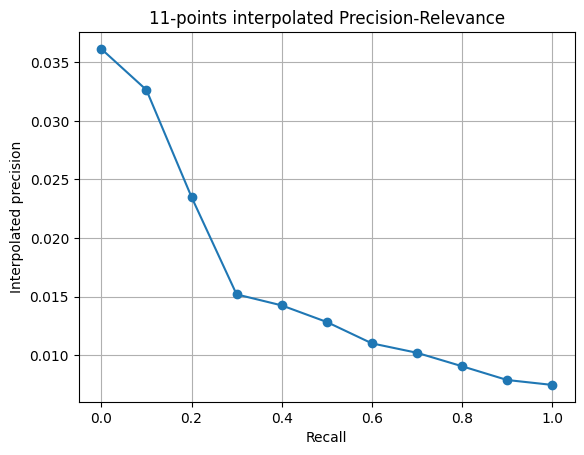

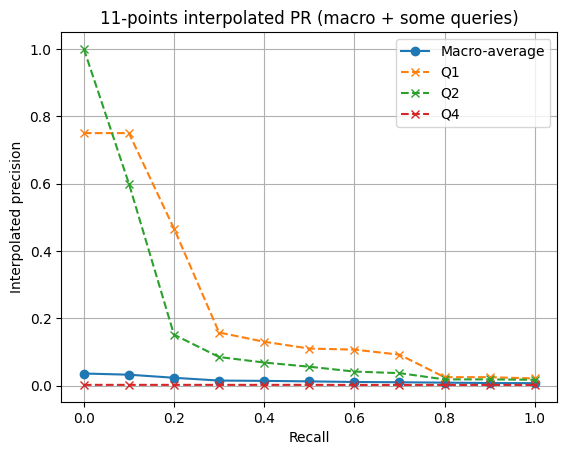

In [16]:
import matplotlib.pyplot as plt

R, pr11_per_query, pr11_macro = pr11_for_all_queries(queries, qrels, jelinek_smoothing)

# Across queries
plt.figure()
plt.plot(R, pr11_macro, marker='o')
plt.xlabel('Recall')
plt.ylabel('Interpolated precision')
plt.title('11-points interpolated Precision-Relevance')
plt.grid(True)
plt.show()

# Per query plots
plt.figure()
plt.plot(R, pr11_macro, marker='o', label='Macro-average')
for qid in list(pr11_per_query.keys())[:3]:
    plt.plot(R, pr11_per_query[qid], marker='x', linestyle='--', label=f'Q{qid}')
plt.xlabel('Recall')
plt.ylabel('Interpolated precision')
plt.title('11-points interpolated PR (macro + some queries)')
plt.legend()
plt.grid(True)
plt.show()
